In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [3]:
fake_df=pd.read_csv(r"C:\Users\druth\OneDrive\Desktop\Projects\fake news detection\Fake.csv")

In [5]:
true_df=pd.read_csv(r"C:\Users\druth\OneDrive\Desktop\Projects\fake news detection\true.csv")

In [7]:
fake_df['label']=0
true_df['label']=1

In [9]:

true_df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [11]:
df=pd.concat([true_df,fake_df])
df=df.sample(frac=1).reset_index(drop=True)

In [13]:
df.head(10)

,title,text,subject,date,label
0,What's in the final Republican tax bill,(Reuters) - The U.S. House of Representatives ...,politicsNews,"December 19, 2017",1
1,Huntington Ingalls wins $2.8 billion U.S. defe...,WASHINGTON (Reuters) - Huntington Ingalls Inc ...,politicsNews,"September 1, 2017",1
2,Trump Stole An Idea From North Korean Propaga...,Jesus f*cking Christ our President* is a moron...,News,"July 14, 2017",0
3,U.S. backs Saudi 'first step' in addressing Ye...,WASHINGTON (Reuters) - The United States on Fr...,worldnews,"November 24, 2017",1
4,Anderson Cooper Demands Answers After Trump’s...,"On Friday, Donald Trump broke a 37-year old pl...",News,"December 3, 2016",0
5,EPA locks in 2025 fuel efficiency rules,WASHINGTON (Reuters) - U.S. Environmental Prot...,politicsNews,"January 13, 2017",1
6,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,Government News,https://fedup.wpengine.com/wp-content/uploads/...,0
7,Biden asks U.S. Congress to allow unencumbered...,WASHINGTON (Reuters) - Vice President Joe Bide...,politicsNews,"September 8, 2016",1
8,TUCKER CARLSON: How The Left Ruined My Alma Ma...,Tucker Carlson and Jesse Waters both went to T...,left-news,"Jun 22, 2017",0
9,"Republican Senator Chokes, Mocks Trump In Bru...","On Wednesday, Senator Pat Toomey (R-PA) gave a...",News,"July 6, 2017",0


In [15]:
print(df['label'].value_counts())

label
0    23481
1    21417
Name: count, dtype: int64


In [17]:
df["content"] = (df["title"].astype(str) + " " + df["text"].astype(str)).fillna("")

C:\Users\druth\AppData\Local\Temp\ipykernel_20848\1833769429.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='subject', data=df, palette='Set2')


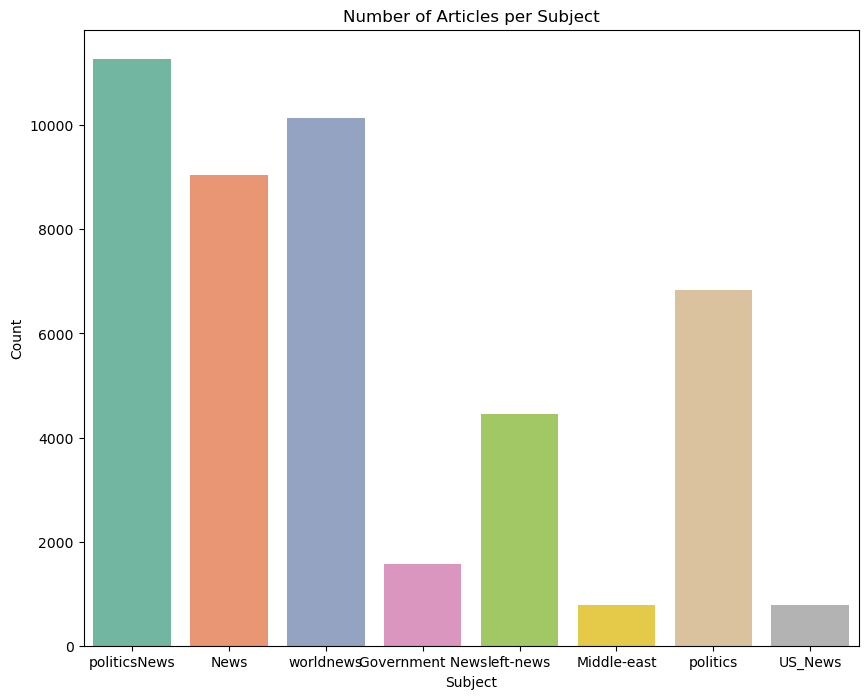

In [19]:
import seaborn as sns 
plt.figure(figsize=(10, 8))
sns.countplot(x='subject', data=df, palette='Set2')
plt.title("Number of Articles per Subject")
plt.xlabel("Subject")
plt.ylabel("Count")
plt.show()

<Figure size 700x500 with 0 Axes>

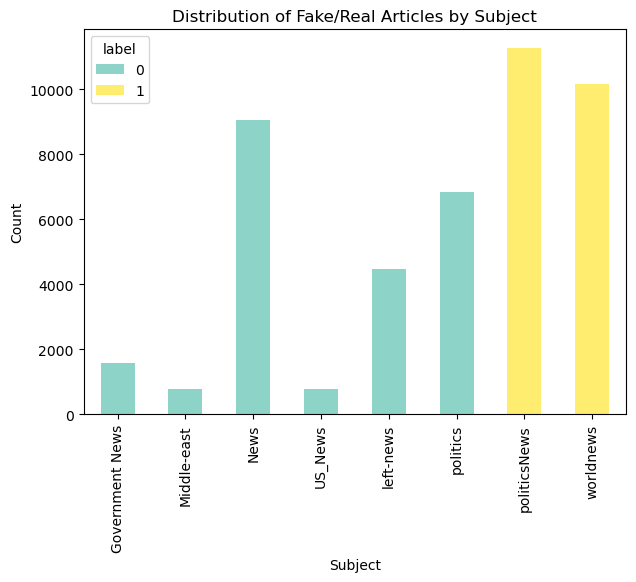

In [21]:
plt.figure(figsize=(7, 5))
pd.crosstab(df['subject'], df['label']).plot(kind='bar', stacked=True, figsize=(7,5), colormap='Set3')
plt.title("Distribution of Fake/Real Articles by Subject")
plt.xlabel("Subject")
plt.ylabel("Count")
plt.show()

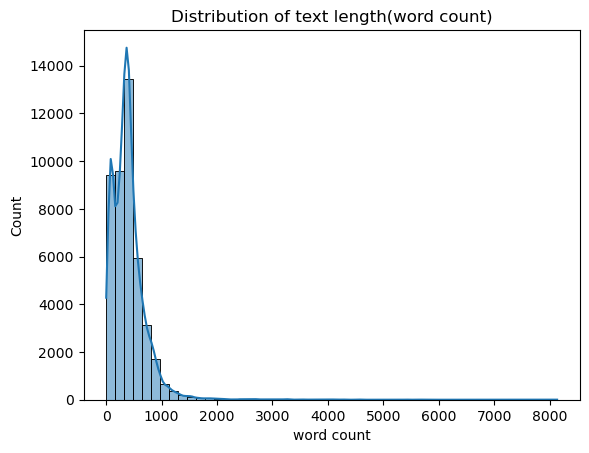

In [23]:
df['text_length']=df['text'].apply(lambda x:len(str(x).split()))
sns.histplot(df['text_length'],bins=50,kde=True)
plt.title("Distribution of text length(word count)")
plt.xlabel("word count")
plt.show()

In [24]:
X= df['content'].astype(str)
Y= df['label']

In [25]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [29]:
! pip install --upgrade imbalanced-learn scikit-learn



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
vectorizer=TfidfVectorizer(stop_words="english",max_df=0.7)
X_train_tfdi=vectorizer.fit_transform(X_train)
X_test_tfdi=vectorizer.transform(X_test)

In [33]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_train_bal,Y_train_bal= smote.fit_resample(X_train_tfdi,Y_train)

In [35]:
print(Y_train.value_counts())
print(Y_test.value_counts())
print(Y_train_bal.value_counts())

label
0    18796
1    17122
Name: count, dtype: int64
label
0    4685
1    4295
Name: count, dtype: int64
label
0    18796
1    18796
Name: count, dtype: int64


In [37]:
log_model=LogisticRegression(max_iter=1000)
log_model.fit(X_train_bal,Y_train_bal)
log_pred=log_model.predict(X_test_tfdi)

In [39]:
nb_model=MultinomialNB()
nb_model.fit(X_train_bal,Y_train_bal)
nb_pred=nb_model.predict(X_test_tfdi)

In [41]:
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train_bal,Y_train_bal)
rf_pred=rf_model.predict(X_test_tfdi)

In [43]:
print("Logistic Regression model accuracy:",accuracy_score(Y_test,log_pred))
print("naive bayes model accuracy:",accuracy_score(Y_test,nb_pred))
print("Random Forest Model accuracy:",accuracy_score(Y_test,rf_pred))

Logistic Regression model accuracy: 0.9868596881959911
naive bayes model accuracy: 0.9398663697104677
Random Forest Model accuracy: 0.9898663697104677


In [45]:
models={"Logistic Regression":(log_model,log_pred),
       "Naive Bayes":(nb_model,nb_pred),
       "RandomForestClassifier":(rf_model,rf_pred)}

for name, (model,pred) in models.items():
    print(f"\n{name} reuslts:")
    print("Accuracy:",accuracy_score(Y_test,pred))
    print("\nClassification Report:\n",classification_report(Y_test,pred))
    print("\nConfusion Metrics\n",confusion_matrix(Y_test,pred))
    print("        ***********            ")


Logistic Regression reuslts:
Accuracy: 0.9868596881959911

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      4685
           1       0.98      0.99      0.99      4295

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980


Confusion Metrics
 [[4615   70]
 [  48 4247]]
        ***********            

Naive Bayes reuslts:
Accuracy: 0.9398663697104677

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.94      0.94      4685
           1       0.93      0.94      0.94      4295

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980


Confusion Metrics
 [[4388  297]
 [ 243 4052]]
        ***********            

RandomForestClassifier reus

In [47]:
results_df = pd.DataFrame(results)

plt.figure(figsize=(7, 5))
sns.barplot(data=results_df, x='Model', y='Accuracy', palette='coolwarm')
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

NameError: name 'results' is not defined

In [50]:
sample_news = [
    "Breaking: Government announces new policy to improve healthcare system",
    "Scientists claim drinking coffee will make you live forever",
    "Donald Trump caught meeting aliens in secret base, sources say"
]

sample_tfdi=vectorizer.transform(sample_news)
prediction=nb_model.predict(sample_tfdi)
print("the sample news is:",prediction)

the sample news is: [1 0 0]


In [52]:
sample_news = [
    """The Prime Minister today unveiled a new healthcare reform bill in parliament.
    The bill aims to reduce costs and improve hospital facilities across the country.""",

    """A Facebook post went viral claiming that scientists discovered a pill that makes people live forever.
    Experts have dismissed the claim as baseless and misleading.""",

    """US President met with NATO leaders to discuss new defense strategies. 
    Officials confirmed that the talks focused on strengthening alliances and trade agreements."""
]

sample_tfidf = vectorizer.transform(sample_news)
predictions = nb_model.predict(sample_tfidf)

for news, pred in zip(sample_news, predictions):
    print("Prediction:", "Real" if pred==1 else "Fake")

Prediction: Real
Prediction: Fake
Prediction: Real
